In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt

# for reproducibility
np.random.seed(0)

In [2]:
# creating simple 2D data

class1 = np.random.randn(50, 2) + [2, 2]
class2 = np.random.randn(50, 2) + [-2, -2]

X = np.vstack((class1, class2))

# labels: +1 and -1
y = np.hstack((np.ones(50), -1 * np.ones(50)))

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 2)
Shape of y: (100,)


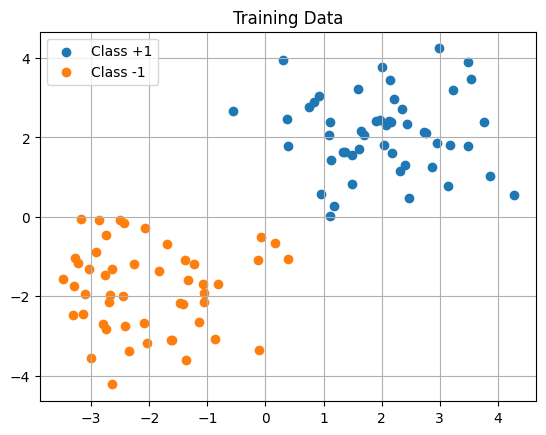

In [3]:
plt.scatter(class1[:,0], class1[:,1], label="Class +1")
plt.scatter(class2[:,0], class2[:,1], label="Class -1")

plt.title("Training Data")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
class Perceptron:
    
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
    
    def activation(self, z):
        # step function
        return np.where(z >= 0, 1, -1)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # training loop
        for epoch in range(self.epochs):
            for i in range(n_samples):
                
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)
                
                # update rule
                if y[i] * y_pred <= 0:
                    self.weights += self.lr * y[i] * X[i]
                    self.bias += self.lr * y[i]
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

In [5]:
model = Perceptron(learning_rate=0.01, epochs=100)
model.fit(X, y)

print("Final Weights:", model.weights)
print("Final Bias:", model.bias)

Final Weights: [0.01229064 0.03366963]
Final Bias: 0.0


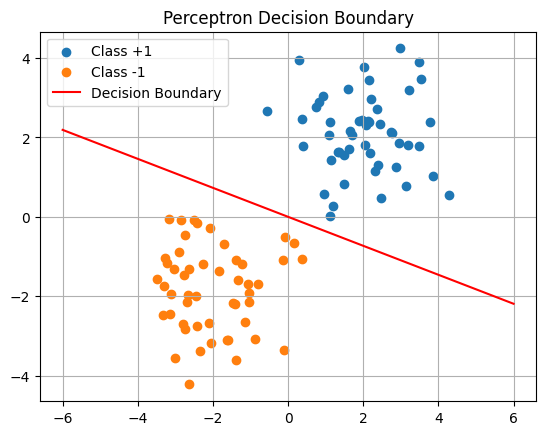

In [6]:
# plot data
plt.scatter(class1[:,0], class1[:,1], label="Class +1")
plt.scatter(class2[:,0], class2[:,1], label="Class -1")

# decision boundary
x_values = np.linspace(-6, 6, 100)
y_values = -(model.weights[0]*x_values + model.bias) / model.weights[1]

plt.plot(x_values, y_values, 'r', label="Decision Boundary")

plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
predictions = model.predict(X)
accuracy = np.mean(predictions == y)

print("Training Accuracy:", accuracy)

Training Accuracy: 1.0
